## Install Libraries

In [ ]:
# Install TensorFlow which includes Keras for building neural networks
# We'll use this to create an autoencoder that compresses and reconstructs images
!pip install -q tensorflow matplotlib numpy

## Building a Simple Autoencoder using keras

This demo constructs a basic autoencoder using MNIST for compression and reconstruction.

✓ Libraries imported successfully
TensorFlow version: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ MNIST data loaded and preprocessed
Training samples: 60000, Test samples: 10000
Input dimension: 784 (28x28 flattened)
✓ Autoencoder model built successfully
Compression ratio: 784/32 = 24.5x


Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_layer (Dense)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Training autoencoder...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.3440 - mae: 0.2098 - val_loss: 0.1670 - val_mae: 0.0853
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1584 - mae: 0.0799 - val_loss: 0.1388 - val_mae: 0.0668
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1365 - mae: 0.0645 - val_loss: 0.1262 - val_mae: 0.0578
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1262 - mae: 0.0573 - val_loss: 0.1189 - val_mae: 0.0525
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1188 - mae: 0.0523 - val_loss: 0.1139 - val_mae: 0.0491
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1145 - mae: 0.0492 - val_loss: 0.1101 - val_mae: 0.0463
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1106 - mae: 0.0465 - val_loss: 0.1068 - val_mae: 0.0439
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1077 - mae: 0.0444 - val_loss: 0.1043 - val_mae: 0.0421
Epoch 9/10
235/235 ━━━━━

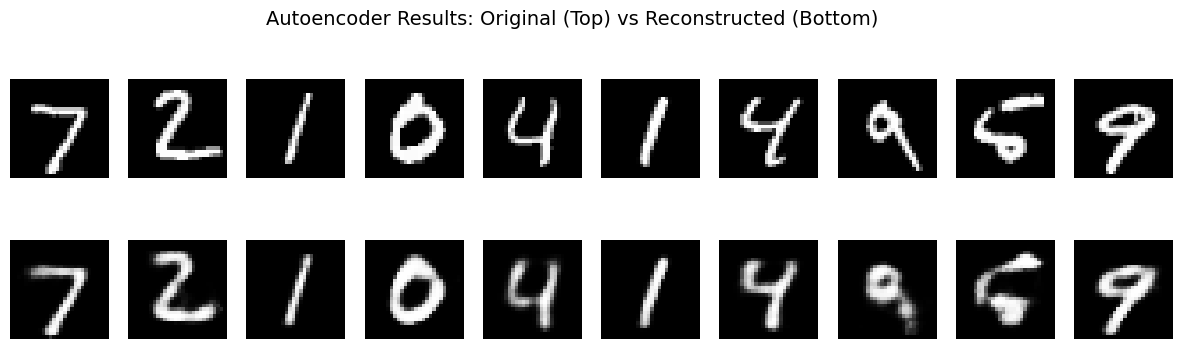

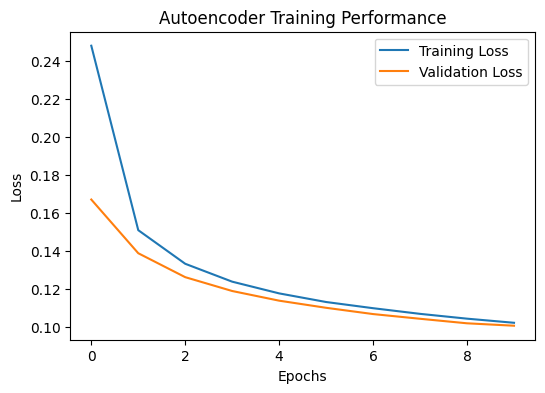


✓ Demo completed!
Average reconstruction error (MSE): 0.0121
Compression achieved: 784 → 32 → 784 dimensions


In [ ]:
# Step 1: Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

# Step 2: Load and preprocess MNIST data
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape((len(x_train), 28 * 28))
x_test = x_test.reshape((len(x_test), 28 * 28))

print(f"✓ MNIST data loaded and preprocessed")
print(f"Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Input dimension: {x_train.shape[1]} (28x28 flattened)")

# Step 3: Build the Autoencoder model
encoding_dim = 32  # bottleneck size

input_layer = keras.Input(shape=(784,), name="input_layer")

# Encoder: 784 → 128 → 64 → 32
encoded = layers.Dense(128, activation='relu', name="encoder_dense_1")(input_layer)
encoded = layers.Dense(64, activation='relu', name="encoder_dense_2")(encoded)
bottleneck = layers.Dense(encoding_dim, activation='relu', name="bottleneck_layer")(encoded)

# Decoder: 32 → 64 → 128 → 784
decoded = layers.Dense(64, activation='relu', name="decoder_dense_1")(bottleneck)
decoded = layers.Dense(128, activation='relu', name="decoder_dense_2")(decoded)
output_layer = layers.Dense(784, activation='sigmoid', name="output_layer")(decoded)

autoencoder = keras.Model(inputs=input_layer, outputs=output_layer, name="autoencoder_model")

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])

print("✓ Autoencoder model built successfully")
print(f"Compression ratio: {784}/{encoding_dim} = {784/encoding_dim:.1f}x")
autoencoder.summary()

# Step 4: Train the autoencoder
print("Training autoencoder...")
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

print("✓ Training completed!")

# Step 5: Evaluate reconstruction
reconstructed = autoencoder.predict(x_test[:10])

original_images = x_test[:10].reshape(10, 28, 28)
reconstructed_images = reconstructed.reshape(10, 28, 28)

# Visualization
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle('Autoencoder Results: Original (Top) vs Reconstructed (Bottom)', fontsize=14)

for i in range(10):
    axes[0, i].imshow(original_images[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed_images[i], cmap='gray')
    axes[1, i].axis('off')

plt.subplots_adjust(top=0.85)
plt.show()

# Step 6: Display learning curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 7: Reconstruction error
mse = np.mean((x_test[:10] - reconstructed) ** 2)
print(f"\n✓ Demo completed!")
print(f"Average reconstruction error (MSE): {mse:.4f}")
print(f"Compression achieved: 784 → {encoding_dim} → 784 dimensions")


## Building an Autoencoder Example - Detecting Abnormal CPU Usage on a Server

This example simulates CPU usage metrics (normal + abnormal spikes) and shows how an autoencoder can detect when a server behaves abnormally — such as unexpected high CPU usage or sudden drops.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Anomaly detection threshold: 0.10195
Detected 15 abnormal CPU usage points.


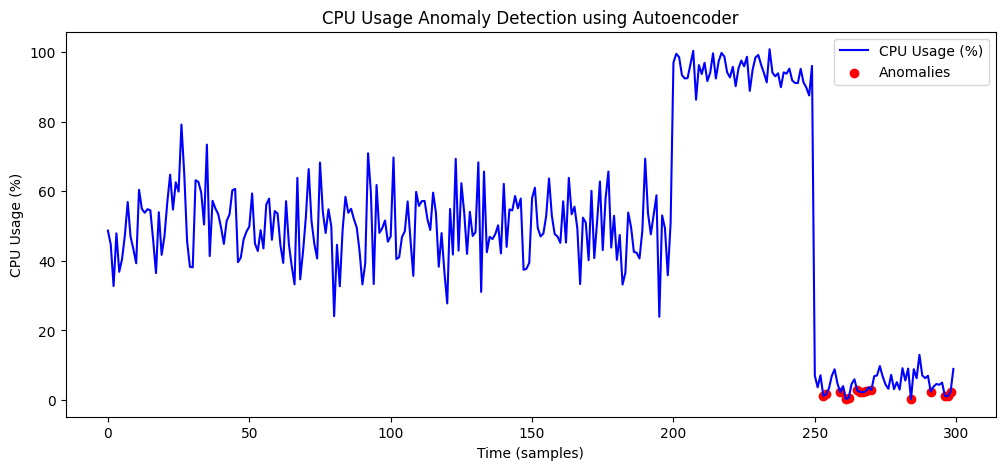

⚠️ Alert: Abnormal CPU usage detected at index 253 → 1.23%
⚠️ Alert: Abnormal CPU usage detected at index 254 → 1.69%
⚠️ Alert: Abnormal CPU usage detected at index 259 → 2.29%
⚠️ Alert: Abnormal CPU usage detected at index 261 → 0.27%
⚠️ Alert: Abnormal CPU usage detected at index 262 → 0.70%
⚠️ Alert: Abnormal CPU usage detected at index 265 → 2.78%
⚠️ Alert: Abnormal CPU usage detected at index 266 → 2.34%
⚠️ Alert: Abnormal CPU usage detected at index 267 → 2.30%
⚠️ Alert: Abnormal CPU usage detected at index 268 → 2.50%
⚠️ Alert: Abnormal CPU usage detected at index 270 → 2.90%
⚠️ Alert: Abnormal CPU usage detected at index 284 → 0.25%
⚠️ Alert: Abnormal CPU usage detected at index 291 → 2.46%
⚠️ Alert: Abnormal CPU usage detected at index 296 → 1.21%
⚠️ Alert: Abnormal CPU usage detected at index 297 → 1.12%
⚠️ Alert: Abnormal CPU usage detected at index 298 → 2.34%


In [ ]:
# Import dependencies
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1️⃣ Simulate Server CPU Usage Data
# ---------------------------------------------------
# Normal CPU usage (in %): mostly between 30–70%
normal_cpu = np.random.normal(loc=50, scale=10, size=(1000, 1))
normal_cpu = np.clip(normal_cpu, 0, 100)  # keep between 0–100%

# Abnormal usage: sudden spikes or drops (e.g., 95%, 5%)
spikes = np.random.normal(loc=95, scale=3, size=(50, 1))
drops = np.random.normal(loc=5, scale=3, size=(50, 1))
abnormal_cpu = np.concatenate([spikes, drops])

# Combine normal + abnormal for testing
x_train = normal_cpu[:800]       # only normal data to train
x_test = np.concatenate([normal_cpu[800:], abnormal_cpu])

# ---------------------------------------------------
# 2️⃣ Normalize Data (very important for neural networks)
# ---------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# ---------------------------------------------------
# 3️⃣ Build the Autoencoder Model
# ---------------------------------------------------
autoencoder = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),  # Bottleneck layer
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="linear")  # Reconstruct original CPU %
])

autoencoder.compile(optimizer="adam", loss="mse")

# ---------------------------------------------------
# 4️⃣ Train Autoencoder on Normal CPU Usage
# ---------------------------------------------------
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# ---------------------------------------------------
# 5️⃣ Predict and Calculate Reconstruction Error
# ---------------------------------------------------
reconstructions = autoencoder.predict(x_test_scaled)
reconstruction_error = np.mean(np.square(x_test_scaled - reconstructions), axis=1)

# ---------------------------------------------------
# 6️⃣ Define Anomaly Threshold
# ---------------------------------------------------
threshold = np.percentile(reconstruction_error, 95)  # top 5% = anomalies
print(f"Anomaly detection threshold: {threshold:.5f}")

# ---------------------------------------------------
# 7️⃣ Identify Anomalies
# ---------------------------------------------------
anomaly_flags = reconstruction_error > threshold

# Mark detected anomalies
detected_anomalies = np.where(anomaly_flags)[0]
print(f"Detected {len(detected_anomalies)} abnormal CPU usage points.")

# ---------------------------------------------------
# 8️⃣ Visualize the Results
# ---------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(x_test, label="CPU Usage (%)", color="blue")
plt.scatter(detected_anomalies, x_test[detected_anomalies], color="red", label="Anomalies")
plt.title("CPU Usage Anomaly Detection using Autoencoder")
plt.xlabel("Time (samples)")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.show()

# ---------------------------------------------------
# 9️⃣ Example: Alert Trigger (optional)
# ---------------------------------------------------
for idx in detected_anomalies:
    print(f"⚠️ Alert: Abnormal CPU usage detected at index {idx} → {x_test[idx][0]:.2f}%")


## Website Monitoring with Autoencoder / Anomaly Detection

you want a realistic website monitoring example that reads actual HTTP response status codes and response times, then detects abnormal behavior.

Here’s a Python example using requests and an autoencoder (or threshold-based logic) to detect anomalies in either status code (non-200 responses) or high response times:


In [ ]:
import requests
import numpy as np
import time
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------------------------------
# 1️⃣ Define URLs to monitor
# ---------------------------------------------------
# urls = ["https://example.com", "https://httpbin.org/status/200"]
urls = ["https://www.microsoft.com/en-us/education/blog/", "https://azure.microsoft.com/en-us/blog"]

# ---------------------------------------------------
# 2️⃣ Function to get response metrics
# ---------------------------------------------------
def get_metrics(url):
    try:
        r = requests.get(url, timeout=5)
        response_time = r.elapsed.total_seconds() * 1000  # convert to ms
        status_code = r.status_code
    except Exception:
        # treat failed request as timeout / error
        response_time = 5000  # 5s as a high response
        status_code = 0       # 0 = failed
    return response_time, status_code

# ---------------------------------------------------
# 3️⃣ Collect training data for "normal" operation
# ---------------------------------------------------
# Example: Assume normal response time < 300ms and status code 200
normal_samples = 100
train_data = []

for _ in range(normal_samples):
    for url in urls:
        rt, sc = get_metrics(url)
        # normalize status_code: 200 -> 0, anything else -> high value
        sc_norm = 0 if sc == 200 else 1
        train_data.append([rt, sc_norm])
    time.sleep(0.1)  # simulate delay between requests

train_data = np.array(train_data)

# ---------------------------------------------------
# 4️⃣ Normalize response times for autoencoder
# ---------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)

# ---------------------------------------------------
# 5️⃣ Build Autoencoder
# ---------------------------------------------------
autoencoder = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(2, activation="relu"),  # bottleneck
    layers.Dense(4, activation="relu"),
    layers.Dense(2, activation="linear")
])
autoencoder.compile(optimizer="adam", loss="mse")

# ---------------------------------------------------
# 6️⃣ Train Autoencoder on normal metrics
# ---------------------------------------------------
autoencoder.fit(train_scaled, train_scaled, epochs=50, batch_size=16, verbose=0)

# ---------------------------------------------------
# 7️⃣ Monitoring Loop (simulate real-time check)
# ---------------------------------------------------
print("Starting website monitoring...\n")
threshold = 0.01  # example threshold for reconstruction error

for i in range(20):  # check 20 times
    for url in urls:
        rt, sc = get_metrics(url)
        sc_norm = 0 if sc == 200 else 1
        sample_scaled = scaler.transform([[rt, sc_norm]])
        recon = autoencoder.predict(sample_scaled, verbose=0)
        error = np.mean((sample_scaled - recon)**2)

        if error > threshold:
            print(f"⚠️ ALERT: Abnormal metrics detected for {url} | "
                  f"Response time={rt:.2f}ms, Status code={sc}, Error={error:.5f}")
        else:
            print(f"✅ OK: {url} | Response time={rt:.2f}ms, Status code={sc}")
    time.sleep(1)


Starting website monitoring...

✅ OK: https://www.microsoft.com/en-us/education/blog/ | Response time=60.38ms, Status code=200
✅ OK: https://azure.microsoft.com/en-us/blog | Response time=27.05ms, Status code=200
✅ OK: https://www.microsoft.com/en-us/education/blog/ | Response time=57.74ms, Status code=200
✅ OK: https://azure.microsoft.com/en-us/blog | Response time=144.05ms, Status code=200
✅ OK: https://www.microsoft.com/en-us/education/blog/ | Response time=86.85ms, Status code=200
✅ OK: https://azure.microsoft.com/en-us/blog | Response time=23.12ms, Status code=200
✅ OK: https://www.microsoft.com/en-us/education/blog/ | Response time=132.26ms, Status code=200
✅ OK: https://azure.microsoft.com/en-us/blog | Response time=32.88ms, Status code=200
✅ OK: https://www.microsoft.com/en-us/education/blog/ | Response time=110.63ms, Status code=200
✅ OK: https://azure.microsoft.com/en-us/blog | Response time=18.37ms, Status code=200
✅ OK: https://www.microsoft.com/en-us/education/blog/ | Resp

## Building a Simple VAE using keras to reconstruct MNIST handwritten digits
##

✓ Libraries imported successfully
TensorFlow version: 2.19.0
✓ MNIST loaded. Input dim: 784, Latent dim: 2
✓ Training Variational Autoencoder...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - kl_loss: 2.9523 - loss: 85.1040 - reconstruction_loss: 82.1517 - val_kl_loss: 2.6394 - val_loss: 58.6210 - val_reconstruction_loss: 55.9816
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - kl_loss: 2.7913 - loss: 59.3455 - reconstruction_loss: 56.5542 - val_kl_loss: 3.1170 - val_loss: 56.5097 - val_reconstruction_loss: 53.3927
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - kl_loss: 3.2157 - loss: 57.5467 - reconstruction_loss: 54.3310 - val_kl_loss: 3.2714 - val_loss: 55.4604 - val_reconstruction_loss: 52.1890
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - kl_loss: 3.4456 - loss: 56.3895 - reconstruction_loss: 52.9439 - val_kl_loss: 3.4762 - val_loss: 54.7796 - val_reconstruction_loss: 51.3034
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - kl_loss: 3.6728

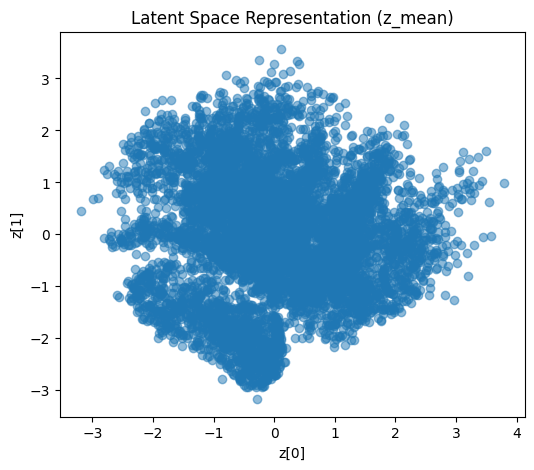

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━

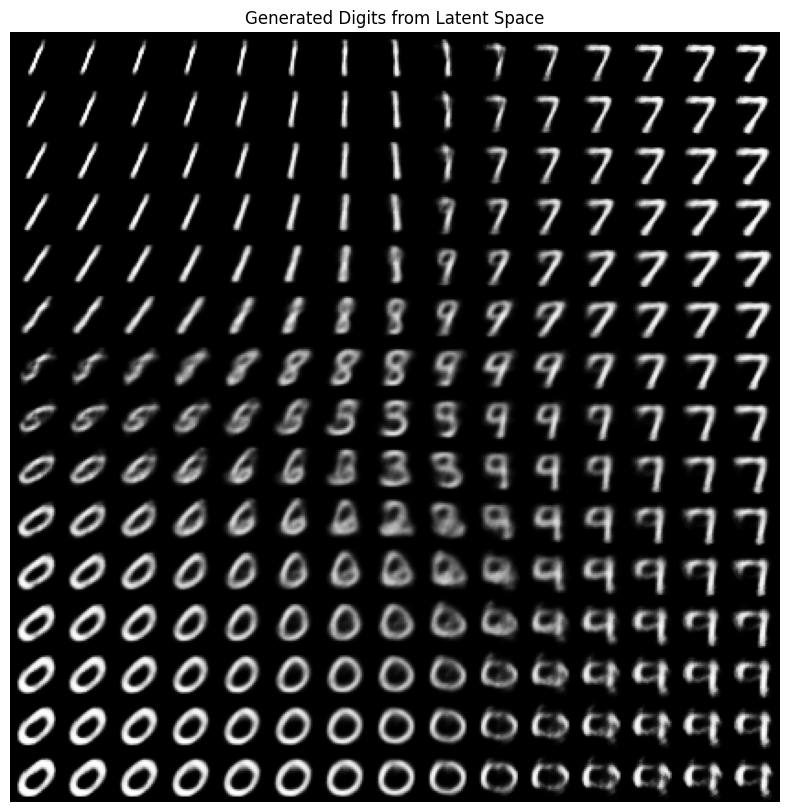

In [ ]:
# Step 1: Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

# Step 2: Load and preprocess MNIST data
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

input_dim = 784
latent_dim = 2

print(f"✓ MNIST loaded. Input dim: {input_dim}, Latent dim: {latent_dim}")

# Step 3: Sampling layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Step 4: Encoder
encoder_inputs = keras.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(512, activation="relu")(encoder_inputs)
x = layers.Dense(256, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Step 5: Decoder
latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
x = layers.Dense(256, activation="relu")(latent_inputs)
x = layers.Dense(512, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# Step 6: VAE model
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_sum(
            keras.losses.binary_crossentropy(data, reconstruction), axis=-1
        )
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_losses(data)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    # ✅ Add this for validation (fixes ValueError)
    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self.compute_losses(data)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Step 7: Train
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

print("✓ Training Variational Autoencoder...")
history = vae.fit(x_train, epochs=10, batch_size=256, validation_data=(x_test,))
print("✓ Training complete!")

# Step 8: Visualize latent space
z_mean, _, _ = encoder.predict(x_test)
plt.figure(figsize=(6, 5))
plt.scatter(z_mean[:, 0], z_mean[:, 1], alpha=0.5)
plt.title("Latent Space Representation (z_mean)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

# Step 9: Generate digits from latent space
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Digits from Latent Space")
plt.show()
